In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pywaffle import Waffle
from matplotlib.colors import ListedColormap

import seaborn as sns
from pywaffle import Waffle


In [4]:
newcmp = ListedColormap(['teal', 'white'])

## Plot number of published papers per year

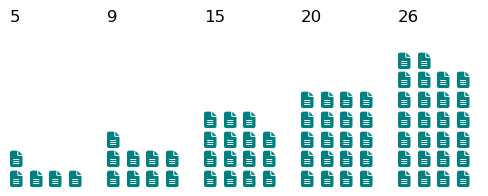

In [17]:
#data = [5,9,14,18,40]
data = [5,9,15,20,26]

N = 30

plots = []

for i, dat in enumerate(data): 

    plots.append({'values': [dat, N-dat],  # Convert actual number to a reasonable block number
            'title': {'label':str(dat), 'loc': 'left', 'fontsize': 12}
            })



newcmp  = ListedColormap(['teal', 'white'])

fig = plt.figure(
    FigureClass=Waffle,
    plots={
        151: plots[0],
        152: plots[1],  
        153: plots[2],
        154: plots[3],
        155: plots[4],
    },
    rows=8,  # Outside parameter applied to all subplots, same as below
    #cols=4,
    cmap_name=newcmp, #"Accent",  # Change color with cmap
    rounding_rule='ceil',  # Change rounding rule, so value less than 1000 will still have at least 1 block
    #starting_location='NW',  # Change starting point to the top left corner
    #block_arranging_style='snake',
    vertical=True,  # Change orientation to vertical
    #theme(legend.position = "none")
    icons = ["file-lines", "truck"], 
    icon_size=12,    
    figsize=(5,3), 
)



plt.tight_layout()
plt.savefig("number_of_methods.pdf", bbox_inches='tight')
plt.show()

## Plot number of covered papers per review

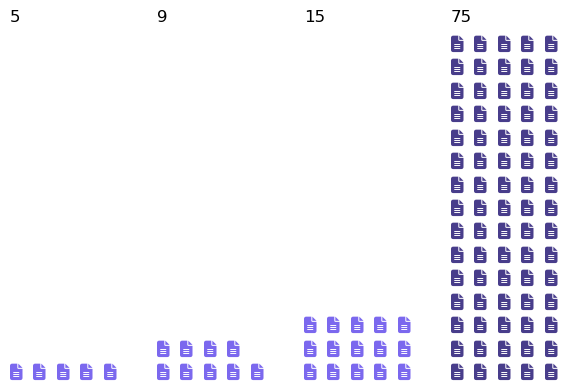

In [19]:
data = [5,9,15,75]
N = 75


plots = []

for i, dat in enumerate(data): 
    if i == 3:  # Last bar (rightmost)
        plots.append({'values': [dat, N-dat],
                'title': {'label':str(dat), 'loc': 'left', 'fontsize': 12}, 
                'rows': 15,  # 6 columns for the last bar (90 blocks / 6 cols = 15 rows)
                'cmap_name': ListedColormap(['darkslateblue', 'white'])  # Different color
                })
    else:
        plots.append({'values': [dat, N-dat],
                'title': {'label':str(dat), 'loc': 'left', 'fontsize': 12}, 
                'rows': 15,
                })

newcmp = ListedColormap(['mediumslateblue', 'white'])

fig = plt.figure(
    FigureClass=Waffle,
    plots={
        141: plots[0],
        142: plots[1],  
        143: plots[2],
        144: plots[3],
    },
    cmap_name=newcmp,
    rounding_rule='ceil',
    icons = ["file-lines", "truck"], 
    icon_size=12,
    vertical=True,
    figsize=(6,4), 
)

plt.tight_layout()
plt.savefig("coverage_of_methods.pdf", bbox_inches='tight')

plt.show()

# Plot number of methods per stage

In [50]:
data = pd.read_csv('vit_papers_v3.csv', header = 1)

data = data.replace({'NaN': 0, " " : 0, "?" : 0, 'x': 1}).fillna(0)

for col in data.columns:
    try:
        numeric_col = pd.to_numeric(data[col], errors='raise') # attempts to convert the column to numeric, raises an error if it fails
        if (numeric_col % 1 == 0).all(): # checks if all values are integers
            data[col] = numeric_col.astype(int)
        else:
            data[col] = numeric_col
    except (ValueError, TypeError) as e:
        # If conversion fails, print the error message and the column name
        print(f"Could not convert column '{col}' to numeric. Error: {e}")
        pass




print(data["Year"].unique())
data = data.query('Year >= 2019')
print(data["Year"].unique())


data["ShortYear"] = data["Year"]-2000
print(data["ShortYear"].unique())#

print(len(data))
data.head()

Could not convert column 'Short Name Identifier' to numeric. Error: Unable to parse string "Transformer Attribution" at position 0
Could not convert column 'Citation Key' to numeric. Error: Unable to parse string "cheferTransformerInterpretabilityAttention2021" at position 0
[2021 2022 2023 2024 2025    0    5    9   14   18   46]
[2021 2022 2023 2024 2025]
[21 22 23 24 25]
75


C:\Users\cwinklm\AppData\Local\Temp\ipykernel_34504\1781806298.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({'NaN': 0, " " : 0, "?" : 0, 'x': 1}).fillna(0)


,Short Name Identifier,Year,Local,Global,Post-hoc,Ante-hoc,Model-specific,Model-class-specific,Model-agnostic,Class-specific,...,Concept-based,Weight-Input-Alignment,Masking-based,Connectivity Constraints,Fantozzi,Kashefi,Stassin,Unnamed: 33,Citation Key,ShortYear
0,Transformer Attribution,2021,1,0,1,0,0,1,0,1,...,0,0,0,0,1,1,1,1,cheferTransformerInterpretabilityAttention2021,21
1,GAE,2021,1,0,1,0,0,1,0,1,...,0,0,0,0,1,1,1,1,cheferGenericAttentionmodelExplainability2021,21
2,IA-RED2,2021,1,0,0,1,0,1,0,0,...,0,0,1,0,0,1,0,1,panIARED2InterpretabilityAwareRedundancy2021,21
3,TAM,2021,1,0,1,0,0,1,0,1,...,0,0,0,0,1,1,0,1,yuanExplainingInformationFlow2021,21
4,RELAX,2021,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,wickstromRELAXRepresentationLearning2023,21


In [51]:
my_data = data[["Post-hoc", "Ante-hoc"]].sum()
print(my_data)

Post-hoc    48
Ante-hoc    27
dtype: int64


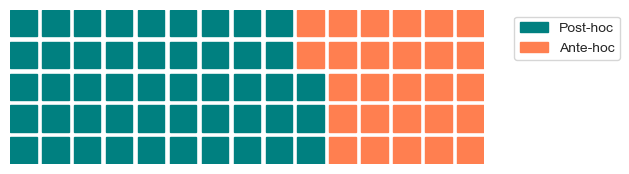

In [55]:
stage = dict(my_data)#{"post-hoc": 50, "ante-hoc": 28}
newcmp  = ListedColormap(['teal', 'coral'])


# Basic waffle
plt.figure(
  FigureClass=Waffle,
  rows=5,
  #columns=5,
  cmap_name = newcmp,
  values=stage,
  legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
)


plt.savefig("stage_of_methods.pdf", bbox_inches='tight')
plt.show()

In [42]:
data.columns

Index(['Short Name Identifier', 'Year', 'Local', 'Global', 'Post-hoc',
       'Ante-hoc', 'Model-specific', 'Model-class-specific', 'Model-agnostic',
       'Class-specific', 'Class-agnostic', 'Prediction', 'Concept',
       'Embedding', 'Patch Interactions', 'Feature Relevance', 'Scalar',
       'Examples', 'Graph', 'Contrastive', 'Text', 'Attention', 'Activation',
       'Perturbations', 'Relevance', 'Gradient', 'Prototype-based',
       'Concept-based', 'Weight-Input-Alignment', 'Masking-based',
       'Connectivity Constraints', 'Fantozzi', 'Kashefi', 'Stassin',
       'Unnamed: 34', 'Citation Key', 'ShortYear'],
      dtype='object')

In [56]:
my_data = data[['Activation', 'Attention', 'Perturbations', 'Relevance', 'Gradient']].sum()
print(dict(my_data))

{'Activation': np.int64(34), 'Attention': np.int64(30), 'Perturbations': np.int64(17), 'Relevance': np.int64(5), 'Gradient': np.int64(20)}


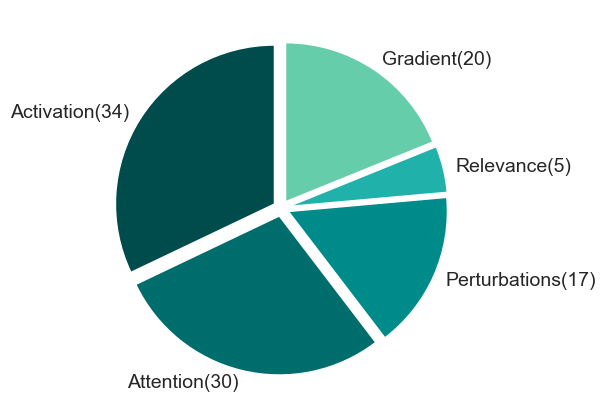

In [57]:
# - thicker white separators via wedgeprops linewidth
# - optional separation via explode
# - larger labels via textprops fontsize


function = dict(my_data)
#{"attention": 31, "gradient": 19, "activation": 11, #"perturbation": 9, "relevance": 2}
names, counts = zip(*function.items())
names = [f"{names[i]}({counts[i]})" for i in range(len(names))]

colors = ["#004c4c", "#006d6d", "#008b8b", "#20b2aa", "#66cdaa"]

explode = [0.05] * len(function)  # set to [0]*len(function) to disable separation

plt.figure(figsize=(6, 6))
sns.set_style("whitegrid")

plt.pie(
    counts,
    labels=names,
    colors=colors,
    explode=explode,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 14},
    labeldistance=1.08
)

plt.title("", fontsize=16)
plt.tight_layout()
plt.savefig("function_of_methods.pdf", bbox_inches='tight')
#plt.show()

In [58]:
colors = ["#FFE5DC", "#FFC7B8", "#FF9E80", "#FF7F50", "#E86A4A"]
colors[0] = "#FFD1C4"  # slightly darker than #FFE5DC


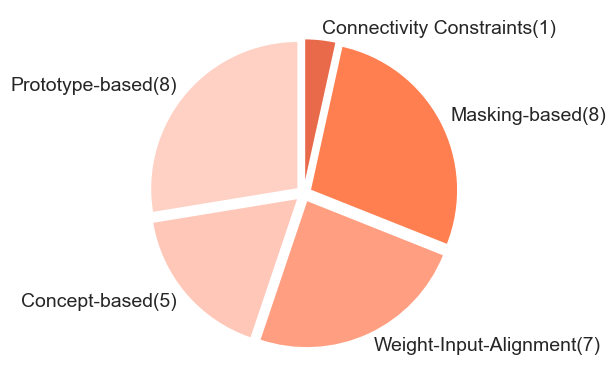

In [59]:
modification = data[['Prototype-based', 'Concept-based', 'Weight-Input-Alignment',
       'Masking-based', 'Connectivity Constraints']].sum()
#{"weight-input alignment": 5, "prototype": 4, "masking": 3, 
 #           "concept": 2, "causality": 1}
colors = ["#FFD1C4", "#FFC7B8", "#FF9E80", "#FF7F50", "#E86A4A"]

names, counts = zip(*modification.items())
names = [f"{names[i]}({counts[i]})" for i in range(len(names))]


explode = [0.05] * len(function)  # set to [0]*len(function) to disable separation

plt.figure(figsize=(6, 6))
sns.set_style("whitegrid")

plt.pie(
    counts,
    labels=names,
    colors=colors,
    explode=explode,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 14},
    labeldistance=1.08
)

plt.title("", fontsize=16)
plt.tight_layout()
plt.savefig("modification_of_methods.pdf", bbox_inches='tight')
plt.show()